# **Assess Fitness App Usage & Calorie Burn Patterns to Drive Personalized Engagement (FitTech)**

`Context`:
A leading fitness technology platform has curated a comprehensive dataset to analyze user
activity patterns, workout engagement, and app feature usage across multiple regions.
The dataset includes daily workout logs, wearable monitoring data, subscription and
profile records, and in-app engagement sessions. 

`WORKFLOW` :
1. Data Cleaning        ✅
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Merge Datasets
5. KPI Creation
6. Business Insights
7. Dashboard / Presentation

### Project Objectives :

#### Primary Objective : `Assess fitness app usage, workout behavior, calorie burn patterns, and user engagement to generate actionable business insights and support personalized user experiences.`



#### Specific Objectives :

1. Analyze user demographics, subscription plans, fitness goals, and workout preferences.
2. Explore workout activity patterns and identify factors influencing calorie expenditure.
3. Evaluate app engagement behavior, feature adoption, purchase activity, and notification effectiveness.
4. Perform statistical analysis to identify relationships between user characteristics, workout behavior, and engagement metrics.
5. Engineer meaningful features and create business KPIs to measure user performance and engagement.
6. Integrate activity, engagement, and user profile datasets using common user identifiers.
7. Use SQL to perform business-focused querying, aggregation, KPI extraction, and reporting.
8. Use Excel to create pivot tables, summary reports, and stakeholder-friendly analytical views.
9. Build interactive Power BI dashboards to visualize workout trends, engagement patterns, and key business metrics.
10. Develop machine learning models to predict user engagement levels or calorie burn outcomes and support data-driven decision-making.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import sqlite3

#The necessary libraries and packages are imported.

# Keep this False while using Run All, so the notebook does not keep creating files.
# Change to True only when you intentionally want to export database, Excel, and model files.
SAVE_OUTPUTS = False

`Data Loading and Inspection`

In [2]:
activity_df = pd.read_excel("/Volumes/Prasanna/NIIT/The Real Capstone Project/Datasets /Activity.xlsx")
app_engagement_df = pd.read_excel("/Volumes/Prasanna/NIIT/The Real Capstone Project/Datasets /App_Engagement.xlsx")
user_profile_df = pd.read_excel("/Volumes/Prasanna/NIIT/The Real Capstone Project/Datasets /User_Profile.xlsx")

activity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Activity_ID          100000 non-null  object        
 1   User_ID              100000 non-null  object        
 2   Date                 100000 non-null  datetime64[ns]
 3   Workout_Type         100000 non-null  object        
 4   Duration_Minutes     100000 non-null  int64         
 5   Calories_Burned      100000 non-null  int64         
 6   Steps_Count          100000 non-null  int64         
 7   Heart_Rate_Avg       100000 non-null  int64         
 8   Workout_Time_of_Day  100000 non-null  object        
 9   Device_Used          100000 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 7.6+ MB


In [3]:
app_engagement_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Session_ID                200000 non-null  object        
 1   User_ID                   200000 non-null  object        
 2   Session_Date              200000 non-null  datetime64[ns]
 3   Feature_Used              200000 non-null  object        
 4   Session_Duration_Minutes  200000 non-null  int64         
 5   In_App_Purchase           200000 non-null  object        
 6   Notification_Clicked      200000 non-null  object        
 7   Workout_Completed         200000 non-null  object        
 8   User_Rating               200000 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 13.7+ MB


In [4]:
user_profile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   User_ID                 600 non-null    object        
 1   Gender                  600 non-null    object        
 2   Age_Group               600 non-null    object        
 3   Region                  600 non-null    object        
 4   Subscription_Type       600 non-null    object        
 5   App_Join_Date           600 non-null    datetime64[ns]
 6   Goal_Type               600 non-null    object        
 7   Preferred_Workout_Type  600 non-null    object        
 8   User_Engagement_Level   600 non-null    object        
dtypes: datetime64[ns](1), object(8)
memory usage: 42.3+ KB


In [5]:
activity_df.head()

,Activity_ID,User_ID,Date,Workout_Type,Duration_Minutes,Calories_Burned,Steps_Count,Heart_Rate_Avg,Workout_Time_of_Day,Device_Used
0,A000001,U1104,2022-10-05,Strength,74,507,0,139,Evening,Mobile
1,A000002,U1460,2021-11-26,Mix,25,153,5658,123,Morning,Web
2,A000003,U1009,2022-02-22,Strength,62,425,0,121,Morning,Mobile
3,A000004,U1547,2023-12-19,Mix,52,318,7405,100,Evening,Mobile
4,A000005,U1448,2024-05-16,Strength,30,226,0,103,Evening,Mobile


In [6]:
app_engagement_df.head()

,Session_ID,User_ID,Session_Date,Feature_Used,Session_Duration_Minutes,In_App_Purchase,Notification_Clicked,Workout_Completed,User_Rating
0,S000001,U1357,2022-05-11,Diet Log,14,Yes,No,Yes,5
1,S000002,U1085,2022-07-22,Workout Tracker,11,No,Yes,No,5
2,S000003,U1584,2021-03-19,Progress,15,No,No,Yes,5
3,S000004,U1455,2022-09-27,Workout Tracker,21,No,Yes,No,4
4,S000005,U1462,2021-04-05,Progress,11,No,No,Yes,5


In [7]:
user_profile_df.head()

,User_ID,Gender,Age_Group,Region,Subscription_Type,App_Join_Date,Goal_Type,Preferred_Workout_Type,User_Engagement_Level
0,U1001,Female,26-35,Bangalore,Premium,2022-03-15,General,Yoga,Medium
1,U1002,Female,26-35,Pune,Trial,2022-07-02,Fitness,Yoga,Medium
2,U1003,Male,36-45,Mumbai,Free,2025-05-14,General,Cardio,Medium
3,U1004,Male,18-25,Chennai,Premium,2022-08-19,Weight Loss,Strength,Medium
4,U1005,Other,36-45,Bangalore,Trial,2023-05-06,General,Mix,Medium


`Dataset Observation` :

- The datasets contain user profile, activity, and app engagement information.
- Numerical and categorical columns are inspected separately before EDA.
- The common key across datasets is `User_ID`.

In [8]:
activity_num_df = activity_df.select_dtypes(include=['int64', 'float64'])

activity_num_df.head()
activity_num_df.describe() #This command gives us simple stats on the activity table.

,Duration_Minutes,Calories_Burned,Steps_Count,Heart_Rate_Avg
count,100000.00000,100000.000000,100000.000000,100000.000000
mean,59.95199,389.442620,2865.635520,119.990760
std,23.36731,191.433721,3486.519408,17.760261
min,20.00000,60.000000,0.000000,90.000000
25%,40.00000,236.000000,0.000000,105.000000
50%,60.00000,357.000000,0.000000,118.000000
75%,80.00000,524.000000,5513.000000,134.000000
max,100.00000,920.000000,12000.000000,160.000000


From the describe function on the activity_df you can see that `The 75th percentile of calories burned is approximately 524 calories`.

In [9]:
app_engagement_num_df = app_engagement_df.select_dtypes(include=['int64', 'float64'])

app_engagement_num_df.head()
app_engagement_num_df.describe() #we do the same for the rest two tables as well

,Session_Duration_Minutes,User_Rating
count,200000.000000,200000.000000
mean,17.826385,4.447825
std,5.134059,0.670641
min,5.000000,3.000000
25%,14.000000,4.000000
50%,18.000000,5.000000
75%,22.000000,5.000000
max,29.000000,5.000000


### Numerical Data Extraction

## *Data Cleaning*

In [10]:
activity_df.duplicated().sum()

np.int64(0)

In [11]:
app_engagement_df.duplicated().sum()

np.int64(0)

In [12]:
user_profile_df.duplicated().sum()

np.int64(0)

`Out of all three datasets no duplicates,no missing values and no null values were found.`

In [13]:
activity_df.dtypes

Activity_ID                    object
User_ID                        object
Date                   datetime64[ns]
Workout_Type                   object
Duration_Minutes                int64
Calories_Burned                 int64
Steps_Count                     int64
Heart_Rate_Avg                  int64
Workout_Time_of_Day            object
Device_Used                    object
dtype: object

`Data Standardization`

In [14]:
categorical_cols = [
    'Workout_Type',
    'Workout_Time_of_Day',
    'Device_Used'
]

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(activity_df[col].value_counts(dropna=False))


Workout_Type
Yoga        25115
Strength    25052
Mix         24925
Cardio      24908
Name: count, dtype: int64

Workout_Time_of_Day
Morning      45089
Evening      39996
Afternoon    14915
Name: count, dtype: int64

Device_Used
Mobile        33455
Web           33373
Smartwatch    33172
Name: count, dtype: int64


In [15]:
activity_df['Activity_ID'].nunique() #checked if all the activity IDs are unique

100000

In [16]:
activity_df['User_ID'].nunique()

600

In [17]:
categorical_cols = [
    'Feature_Used',
    'In_App_Purchase',
    'Notification_Clicked',
    'Workout_Completed'
]

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(app_engagement_df[col].value_counts(dropna=False))


Feature_Used
Workout Tracker    79565
Progress           50228
Diet Log           40053
Community          30154
Name: count, dtype: int64

In_App_Purchase
No     172339
Yes     27661
Name: count, dtype: int64

Notification_Clicked
No     126976
Yes     73024
Name: count, dtype: int64

Workout_Completed
Yes    150089
No      49911
Name: count, dtype: int64


In [18]:
categorical_cols = [
    'Gender',
    'Age_Group',
    'Region',
    'Subscription_Type',
    'Goal_Type',
    'Preferred_Workout_Type'
]

for col in categorical_cols:  
   print(user_profile_df[col].value_counts(dropna=False)) 

Gender
Male      277
Female    265
Other      58
Name: count, dtype: int64
Age_Group
26-35    244
18-25    178
36-45    131
46+       47
Name: count, dtype: int64
Region
Mumbai       108
Bangalore     86
Pune          84
Delhi NCR     84
Kolkata       82
Chennai       78
Hyderabad     78
Name: count, dtype: int64
Subscription_Type
Free       293
Premium    249
Trial       58
Name: count, dtype: int64
Goal_Type
Fitness        163
Strength       152
General        146
Weight Loss    139
Name: count, dtype: int64
Preferred_Workout_Type
Yoga        159
Cardio      150
Strength    146
Mix         145
Name: count, dtype: int64


In [ ]:
user_profile_df['User_Engagement_Level'].head()

`UPDATE` :
An earlier version of this source file had `User_Engagement_Level` set to `Medium` for every single user (no real signal). That has since been corrected upstream: the column now carries genuine, balanced labels (200 users each of `Low` / `Medium` / `High`). It is **kept** here and used later as the real classification target in Objective 10, validated against a behavior-based score derived independently in Objective 6.

In [ ]:
user_profile_df['User_Engagement_Level'].value_counts()

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=user_profile_df,
    x='User_Engagement_Level',
    order=['Low', 'Medium', 'High'],
    palette=['#EC4899', '#8B5CF6', '#10B981']
)
plt.title('User Count by Engagement Level')
plt.xlabel('Engagement Level')
plt.ylabel('Number of Users')
plt.show()

**Insight:** The three engagement tiers are perfectly balanced (200 users each). Section Objective 6 checks whether this label actually lines up with real behavior, before it gets used as the classification target in Objective 10.

In [ ]:
activity_df.shape
#app_engagement_df.shape
#user_profile_df.shape

(100000, 10)

`DATA QUALITY SUMMARY`

- Duplicate checks were performed for all three datasets.
- Categorical columns were reviewed for consistency.
- The profile dataset was aligned with the required project schema before EDA.

## *Exploratory Data Analysis*

## User Profile Analysis

### Who uses the app?

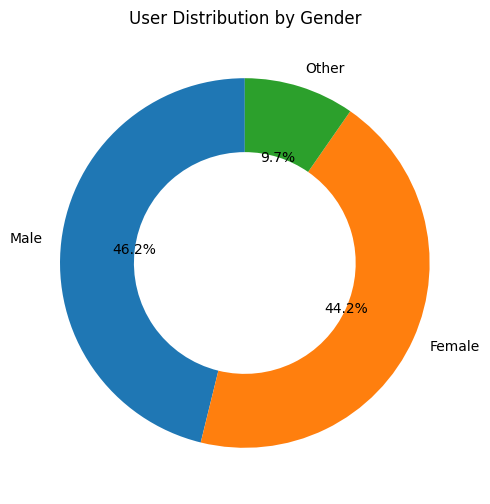

In [ ]:
gender_counts = user_profile_df['Gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts,
    labels=gender_counts.index, # type: ignore
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)
plt.title('User Distribution by Gender')
plt.show()

**Insight:** Male users form the largest gender segment with 277 users, about 46.2% of the user base.

### Which age groups use the platform most frequently?

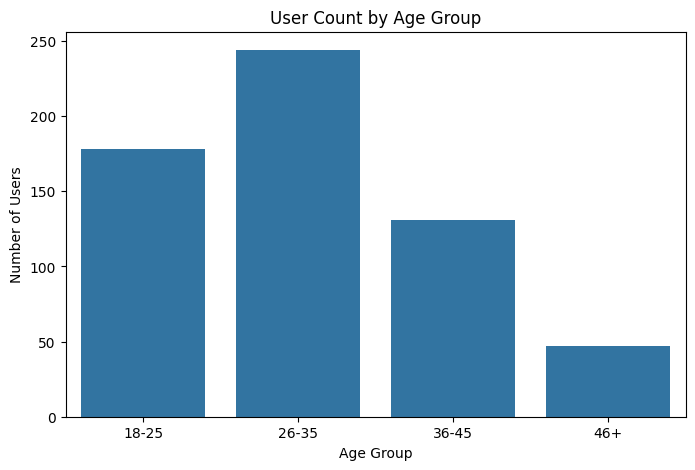

In [ ]:
age_order = ['18-25', '26-35', '36-45', '46+']

plt.figure(figsize=(8, 5))
sns.countplot(
    data=user_profile_df,
    x='Age_Group',
    order=age_order
)
plt.title('User Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Users')
plt.show()

**Insight:** The 26-35 age group has the highest usage with 244 users, representing about 40.7% of users.

### Which regions contribute the most users?

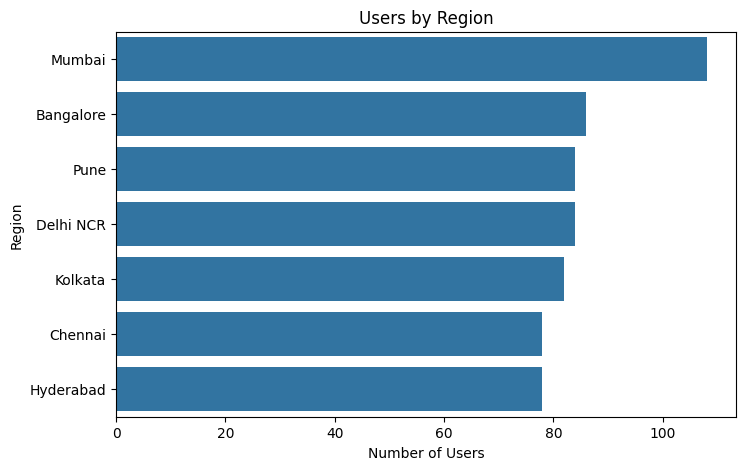

In [ ]:
region_counts = user_profile_df['Region'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=region_counts.values,
    y=region_counts.index
)
plt.title('Users by Region')
plt.xlabel('Number of Users')
plt.ylabel('Region')
plt.show()

**Insight:** Mumbai contributes the most users with 108 users, accounting for 18.0% of the profile dataset.

### Which subscription plans are most popular?

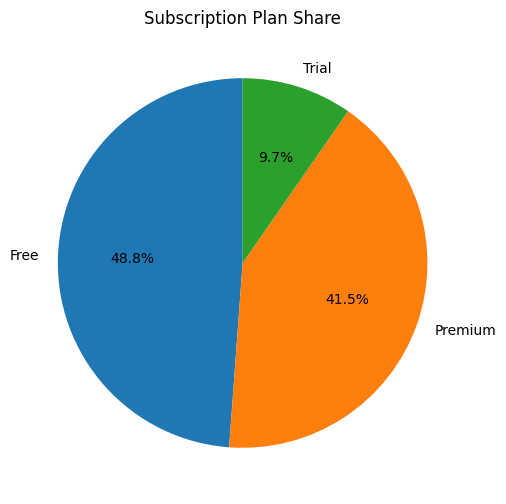

In [ ]:
subscription_counts = user_profile_df['Subscription_Type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    subscription_counts,
    labels=subscription_counts.index, # type: ignore
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Subscription Plan Share')
plt.show()

**Insight:** The Free plan is the most popular subscription type with 293 users, about 48.8% of users.

### What are users trying to achieve?

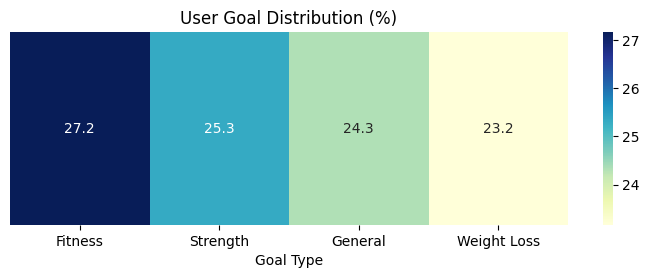

In [ ]:
goal_percent = user_profile_df['Goal_Type'].value_counts(normalize=True) * 100
goal_percent_df = pd.DataFrame([goal_percent.values], columns=goal_percent.index)

plt.figure(figsize=(9, 2.5))
sns.heatmap(
    goal_percent_df,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)
plt.title('User Goal Distribution (%)')
plt.xlabel('Goal Type')
plt.yticks([])
plt.show()

**Insight:** Fitness is the leading user goal with 163 users, representing about 27.2% of the user base.

### Which workouts are preferred by users?

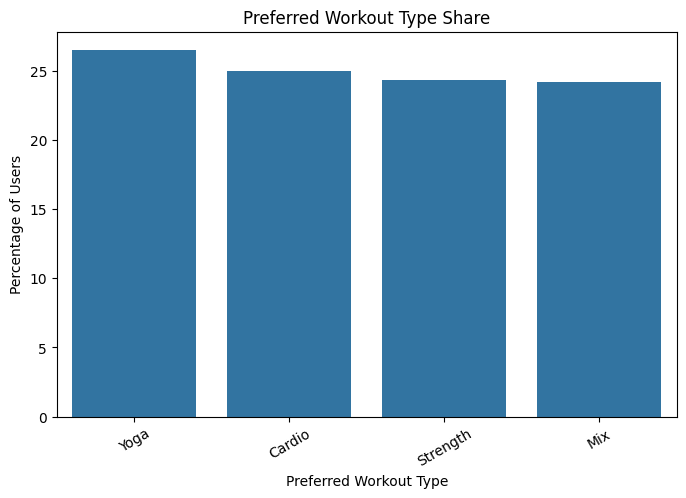

In [ ]:
preferred_workout_percent = user_profile_df['Preferred_Workout_Type'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
sns.barplot(
    x=preferred_workout_percent.index,
    y=preferred_workout_percent.values
)
plt.title('Preferred Workout Type Share')
plt.xlabel('Preferred Workout Type')
plt.ylabel('Percentage of Users')
plt.xticks(rotation=30)
plt.show()

**Insight:** Yoga is the most preferred workout type with 159 users, about 26.5% of users.

## Activity Analysis

### Which workout types are most popular?

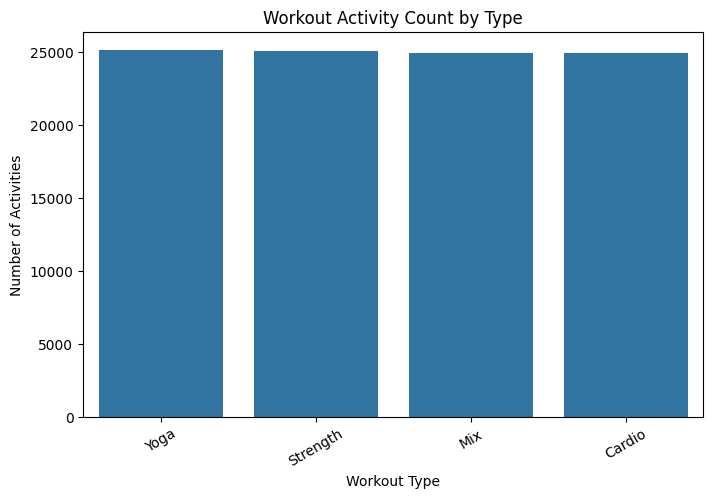

In [ ]:
workout_order = activity_df['Workout_Type'].value_counts().index

plt.figure(figsize=(8, 5))
sns.countplot(
    data=activity_df,
    x='Workout_Type',
    order=workout_order
)
plt.title('Workout Activity Count by Type')
plt.xlabel('Workout Type')
plt.ylabel('Number of Activities')
plt.xticks(rotation=30)
plt.show()

**Insight:** Yoga is the most recorded workout type with 25,115 activity records, about 25.1% of all workouts.

### Which workout types burn the most calories?

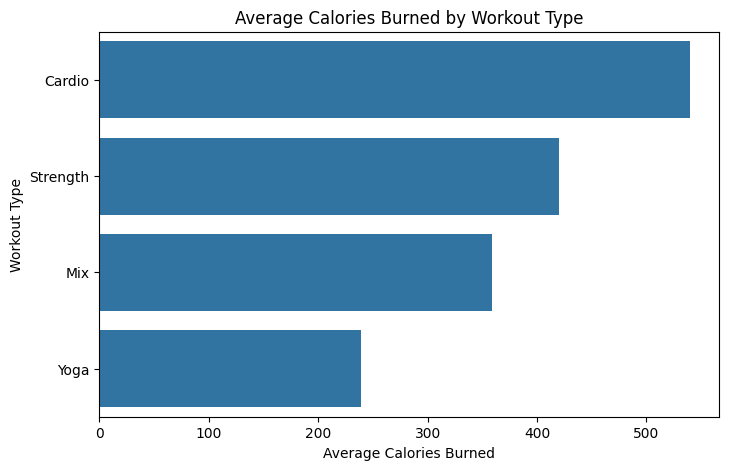

In [ ]:
avg_calories = activity_df.groupby('Workout_Type')['Calories_Burned'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=avg_calories.values,
    y=avg_calories.index
)
plt.title('Average Calories Burned by Workout Type')
plt.xlabel('Average Calories Burned')
plt.ylabel('Workout Type')
plt.show()

**Insight:** Cardio has the highest average calorie burn at about 539.7 calories per workout.

### When do users exercise?

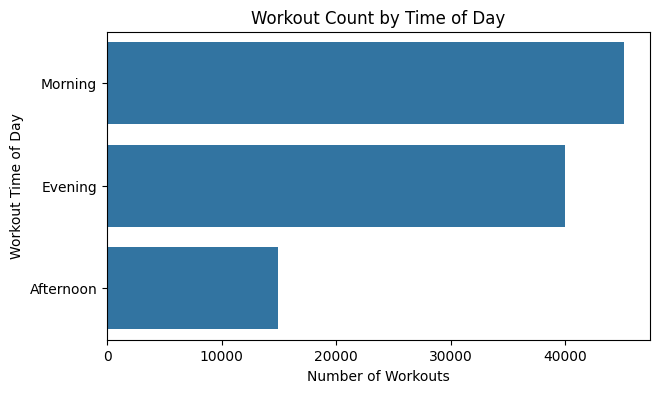

In [ ]:
time_counts = activity_df['Workout_Time_of_Day'].value_counts()

plt.figure(figsize=(7, 4))
sns.barplot(
    x=time_counts.values,
    y=time_counts.index
)
plt.title('Workout Count by Time of Day')
plt.xlabel('Number of Workouts')
plt.ylabel('Workout Time of Day')
plt.show()

**Insight:** Morning is the most common workout time with 45,089 sessions, about 45.1% of all workouts.

### Which devices are most commonly used?

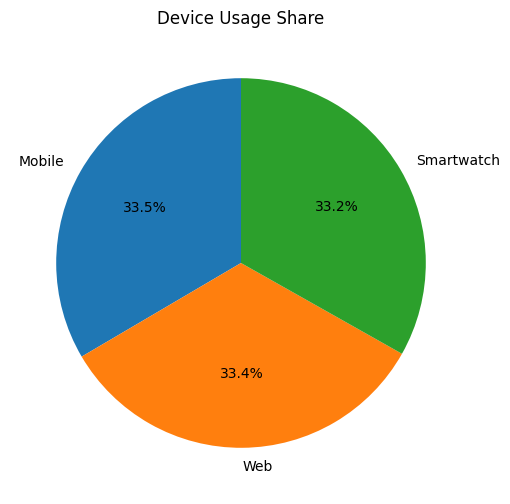

In [ ]:
device_counts = activity_df['Device_Used'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    device_counts,
    labels=device_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Device Usage Share')
plt.show()

**Insight:** Mobile is the most commonly used device with 33,455 workout records, about 33.5% of activity entries.

### How are calories burned distributed?

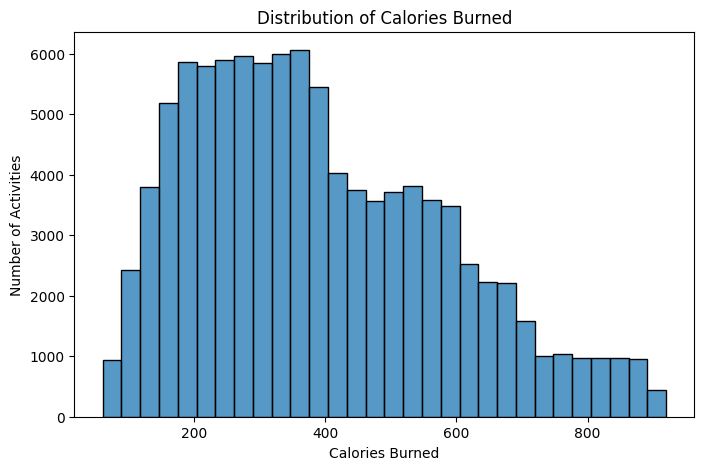

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=activity_df,
    x='Calories_Burned',
    bins=30
)
plt.title('Distribution of Calories Burned')
plt.xlabel('Calories Burned')
plt.ylabel('Number of Activities')
plt.show()

**Insight:** Calories burned has a median of 357 calories, with the middle 50% of workouts between 236 and 524 calories.

### How is workout duration distributed?

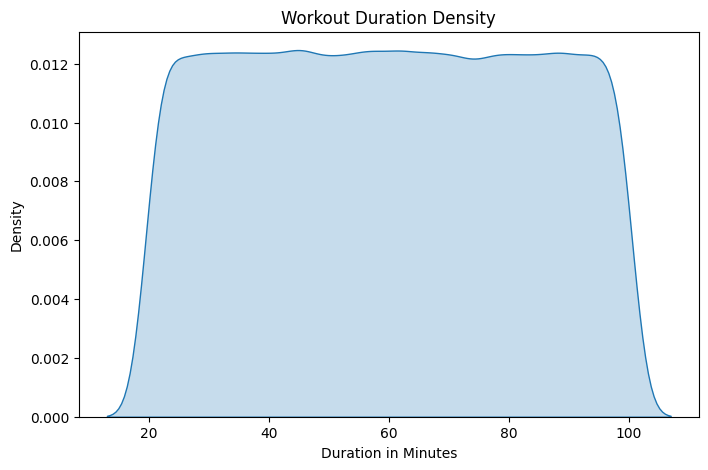

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=activity_df,
    x='Duration_Minutes',
    fill=True
)
plt.title('Workout Duration Density')
plt.xlabel('Duration in Minutes')
plt.ylabel('Density')
plt.show()

**Insight:** Workout duration centers around 60 minutes, with the middle 50% of sessions between 40 and 80 minutes.

### How are daily steps distributed?

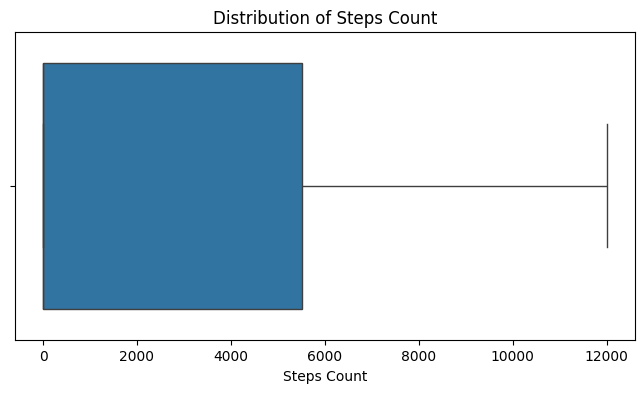

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=activity_df,
    x='Steps_Count'
)
plt.title('Distribution of Steps Count')
plt.xlabel('Steps Count')
plt.show()

**Insight:** Steps count has a median of 0 and a wide upper spread, with the top quartile starting around 5,513 steps.

## Engagement Analysis

### Which features are used most?

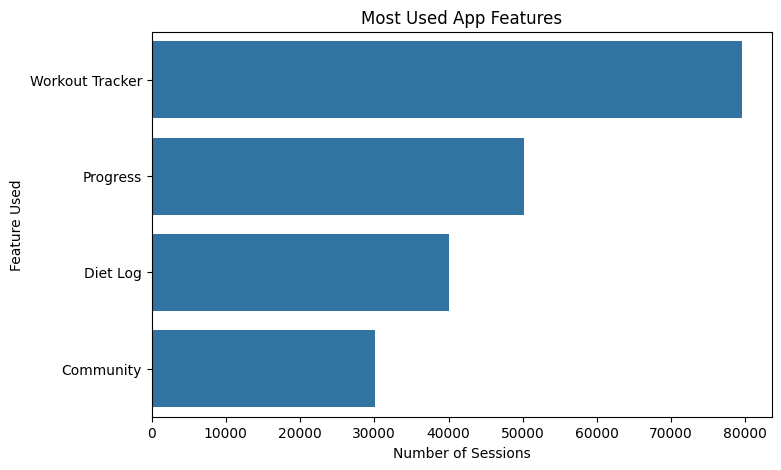

In [ ]:
feature_counts = app_engagement_df['Feature_Used'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=feature_counts.values,
    y=feature_counts.index
)
plt.title('Most Used App Features')
plt.xlabel('Number of Sessions')
plt.ylabel('Feature Used')
plt.show()

**Insight:** Workout Tracker is the most used feature with 79,565 sessions, about 39.8% of app engagement records.

### Are notifications effective?

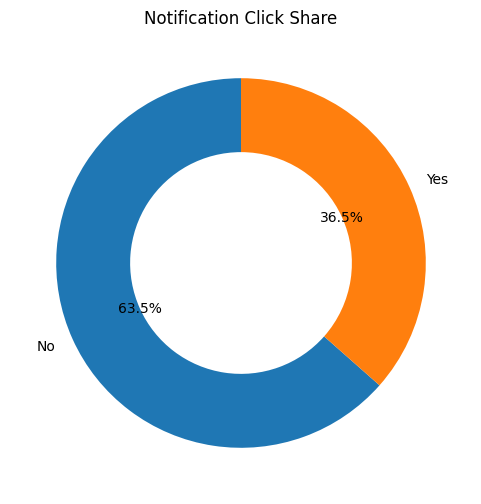

In [ ]:
notification_counts = app_engagement_df['Notification_Clicked'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    notification_counts,
    labels=notification_counts.index, # type: ignore
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)
plt.title('Notification Click Share')
plt.show()

**Insight:** Notifications were clicked in 73,024 sessions, giving a click rate of about 36.5%.

### Are users completing workouts?

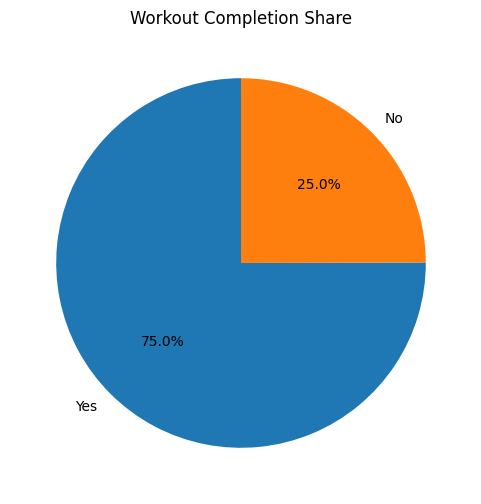

In [ ]:
completion_counts = app_engagement_df['Workout_Completed'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    completion_counts,
    labels=completion_counts.index, # type: ignore
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Workout Completion Share')
plt.show()

**Insight:** Users completed workouts in 150,089 sessions, giving a completion rate of about 75.0%.

### Are users making in-app purchases?

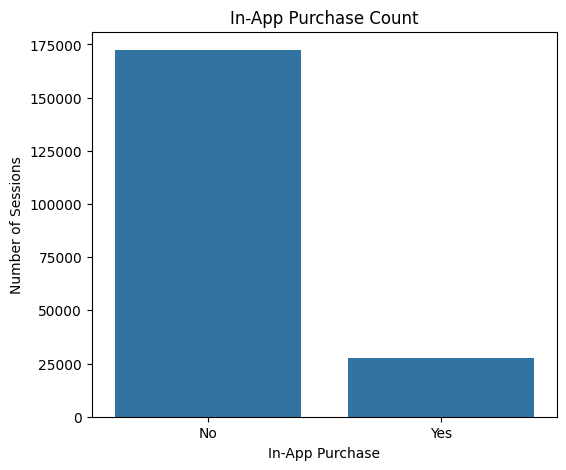

In [ ]:
purchase_order = app_engagement_df['In_App_Purchase'].value_counts().index

plt.figure(figsize=(6, 5))
sns.countplot(
    data=app_engagement_df,
    x='In_App_Purchase',
    order=purchase_order
)
plt.title('In-App Purchase Count')
plt.xlabel('In-App Purchase')
plt.ylabel('Number of Sessions')
plt.show()

**Insight:** In-app purchases occurred in 27,661 sessions, about 13.8% of engagement records.

### How is session duration distributed?

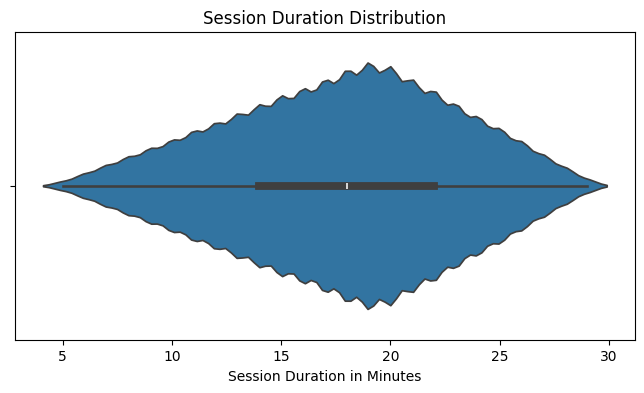

In [ ]:
plt.figure(figsize=(8, 4))
sns.violinplot(
    data=app_engagement_df,
    x='Session_Duration_Minutes'
)
plt.title('Session Duration Distribution')
plt.xlabel('Session Duration in Minutes')
plt.show()

**Insight:** Session duration has a median of 18 minutes, with the middle 50% of sessions between 14 and 22 minutes.

## Objective 4: Basic Statistical Analysis

**Question:** Which numerical workout variables are related to each other?

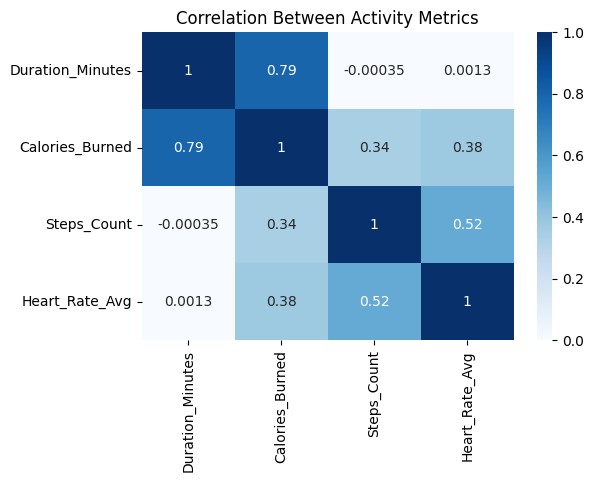

In [ ]:
activity_corr = activity_df[['Duration_Minutes', 'Calories_Burned', 'Steps_Count','Heart_Rate_Avg']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(activity_corr, annot=True, cmap='Blues')
plt.title('Correlation Between Activity Metrics')
plt.show()

**Insight:** This helps check whether longer workouts, higher calorie burn and step count move together.

**Question:** Which workout type has the highest average calorie burn?

In [ ]:
avg_calories_by_workout = activity_df.groupby('Workout_Type')['Calories_Burned'].mean().sort_values(ascending=False)

avg_calories_by_workout

Workout_Type
Cardio      539.675205
Strength    420.408231
Mix         359.248265
Yoga        239.526259
Name: Calories_Burned, dtype: float64

**Insight:** This simple groupby shows which workout type burns more calories on average.

**Question:** Which app features have the longest average session duration?

In [ ]:
avg_session_by_feature = app_engagement_df.groupby('Feature_Used')['Session_Duration_Minutes'].mean().sort_values(ascending=False)

avg_session_by_feature

Feature_Used
Workout Tracker    17.851882
Diet Log           17.839463
Progress           17.799654
Community          17.786264
Name: Session_Duration_Minutes, dtype: float64

**Insight:** This shows which features keep users engaged for more time.

**Question:** How are subscription type and fitness goal related?

In [ ]:
subscription_goal_table = pd.crosstab(
    user_profile_df['Subscription_Type'],
    user_profile_df['Goal_Type']
)

subscription_goal_table

Goal_Type,Fitness,General,Strength,Weight Loss
Subscription_Type,,,,
Free,76,68,84,65
Premium,73,64,53,59
Trial,14,14,15,15


**Insight:** This table helps compare user goals across different subscription plans.

### Hypothesis Testing

In [ ]:
from scipy import stats

**Test 1: Do different workout types burn different average calories?**

- Null Hypothesis (H0): Average calories burned is the same for all workout types.
- Alternate Hypothesis (H1): At least one workout type has a different average calorie burn.

In [ ]:
cardio = activity_df[activity_df['Workout_Type'] == 'Cardio']['Calories_Burned']
strength = activity_df[activity_df['Workout_Type'] == 'Strength']['Calories_Burned']
yoga = activity_df[activity_df['Workout_Type'] == 'Yoga']['Calories_Burned']
mix = activity_df[activity_df['Workout_Type'] == 'Mix']['Calories_Burned']

f_stat, p_value = stats.f_oneway(cardio, strength, yoga, mix)

print('F-statistic:', round(f_stat, 2))
print('P-value:', p_value)

if p_value < 0.05:
    print('Conclusion: Reject H0. Average calories burned differs by workout type.')
else:
    print('Conclusion: Fail to reject H0. No significant difference found.')

F-statistic: 15699.11
P-value: 0.0
Conclusion: Reject H0. Average calories burned differs by workout type.


**Insight:** This test checks whether workout type has a statistically significant relationship with calorie burn.

**Test 2: Are notification clicks and workout completion related?**

- Null Hypothesis (H0): Notification clicks and workout completion are independent.
- Alternate Hypothesis (H1): Notification clicks and workout completion are related.

In [ ]:
notification_completion_table = pd.crosstab(
    app_engagement_df['Notification_Clicked'],
    app_engagement_df['Workout_Completed']
)

chi2, p_value, dof, expected = stats.chi2_contingency(notification_completion_table)

print(notification_completion_table)
print('Chi-square statistic:', round(chi2, 2)) # type: ignore
print('P-value:', p_value)

if p_value < 0.05: # type: ignore
    print('Conclusion: Reject H0. Notification clicks and workout completion are related.')
else:
    print('Conclusion: Fail to reject H0. No significant relationship found.')

Workout_Completed        No    Yes
Notification_Clicked              
No                    31598  95378
Yes                   18313  54711
Chi-square statistic: 0.91
P-value: 0.3395283784443724
Conclusion: Fail to reject H0. No significant relationship found.


**Insight:** This test helps understand whether notification engagement is connected with workout completion.

**Test 3: Do clicked notifications have a different average session duration?**

- Null Hypothesis (H0): Average session duration is the same for clicked and not-clicked notifications.
- Alternate Hypothesis (H1): Average session duration is different for clicked and not-clicked notifications.

In [ ]:
clicked_sessions = app_engagement_df[app_engagement_df['Notification_Clicked'] == 'Yes']['Session_Duration_Minutes']
not_clicked_sessions = app_engagement_df[app_engagement_df['Notification_Clicked'] == 'No']['Session_Duration_Minutes']

t_stat, p_value = stats.ttest_ind(clicked_sessions, not_clicked_sessions, equal_var=False)

print('T-statistic:', round(t_stat, 2)) # type: ignore
print('P-value:', p_value)

if p_value < 0.05: # type: ignore
    print('Conclusion: Reject H0. Session duration differs based on notification click status.')
else:
    print('Conclusion: Fail to reject H0. No significant difference found.')

T-statistic: 1.22
P-value: 0.22221808911742622
Conclusion: Fail to reject H0. No significant difference found.


**Insight:** This test checks whether users who click notifications spend a different amount of time in the app.

### Validation Summary

In [ ]:
anova_p_value = stats.f_oneway(cardio, strength, yoga, mix).pvalue

chi2_table = pd.crosstab(
    app_engagement_df['Notification_Clicked'],
    app_engagement_df['Workout_Completed']
)
chi2_p_value = stats.chi2_contingency(chi2_table)[1]

ttest_p_value = stats.ttest_ind(
    clicked_sessions,
    not_clicked_sessions,
    equal_var=False
).pvalue

validation_summary = pd.DataFrame({
    'Test': [
        'ANOVA - Calories by Workout Type',
        'Chi-square - Notification Click vs Completion',
        'T-test - Session Duration by Notification Click'
    ],
    'P_Value': [anova_p_value, chi2_p_value, ttest_p_value],
    'Decision': [
        'Significant' if anova_p_value < 0.05 else 'Not Significant',
        'Significant' if chi2_p_value < 0.05 else 'Not Significant',
        'Significant' if ttest_p_value < 0.05 else 'Not Significant'
    ]
})

validation_summary

,Test,P_Value,Decision
0,ANOVA - Calories by Workout Type,0.000000,Significant
1,Chi-square - Notification Click vs Completion,0.339528,Not Significant
2,T-test - Session Duration by Notification Click,0.222218,Not Significant


In [ ]:
if SAVE_OUTPUTS:
    validation_summary.to_excel(
        'Validation_Summary.xlsx',
        index=False
    )
    print('Validation_Summary.xlsx saved.')
else:
    print('File export skipped. Set SAVE_OUTPUTS = True to save Validation_Summary.xlsx.')

File export skipped. Set SAVE_OUTPUTS = True to save Validation_Summary.xlsx.


**Insight:** This creates a simple validation report showing which statistical tests are significant.

## Objective 5: Basic Feature Engineering

**Note:** Simple feature engineering can be done before merging. Features that need columns from multiple datasets should be created after objective 6, when the datasets are merged.

**Activity Features**

In [ ]:
activity_df['Calories_Per_Minute'] = activity_df['Calories_Burned'] / activity_df['Duration_Minutes']

activity_df['Duration_Category'] = pd.cut(
    activity_df['Duration_Minutes'],
    bins=[0, 30, 60, 100],
    labels=['Short', 'Medium', 'Long']
)

activity_df['Steps_Category'] = pd.cut(
    activity_df['Steps_Count'],
    bins=[-1, 3000, 7000, 12000],
    labels=['Low Steps', 'Medium Steps', 'High Steps']
)

activity_df[['Duration_Minutes', 'Calories_Burned', 'Calories_Per_Minute', 'Duration_Category', 'Steps_Count', 'Steps_Category']].head()

,Duration_Minutes,Calories_Burned,Calories_Per_Minute,Duration_Category,Steps_Count,Steps_Category
0,74,507,6.851351,Long,0,Low Steps
1,25,153,6.120000,Short,5658,Medium Steps
2,62,425,6.854839,Long,0,Low Steps
3,52,318,6.115385,Medium,7405,High Steps
4,30,226,7.533333,Short,0,Low Steps


**Insight:** These columns make workout intensity and activity level easier to compare.

**Engagement Features**

In [ ]:
app_engagement_df['Notification_Clicked_Flag'] = app_engagement_df['Notification_Clicked'].map({'Yes': 1, 'No': 0})
app_engagement_df['Workout_Completed_Flag'] = app_engagement_df['Workout_Completed'].map({'Yes': 1, 'No': 0})
app_engagement_df['Purchase_Flag'] = app_engagement_df['In_App_Purchase'].map({'Yes': 1, 'No': 0})

app_engagement_df['Session_Duration_Category'] = pd.cut(
    app_engagement_df['Session_Duration_Minutes'],
    bins=[0, 10, 20, 30],
    labels=['Short', 'Medium', 'Long']
)

app_engagement_df[['Session_Duration_Minutes', 'Session_Duration_Category', 'Notification_Clicked_Flag', 'Workout_Completed_Flag', 'Purchase_Flag']].head()

,Session_Duration_Minutes,Session_Duration_Category,Notification_Clicked_Flag,Workout_Completed_Flag,Purchase_Flag
0,14,Medium,0,1,1
1,11,Medium,1,0,0
2,15,Medium,0,1,0
3,21,Long,1,0,0
4,11,Medium,0,1,0


**Insight:** These flag columns make yes/no engagement behavior easier to calculate later.

**User Profile Features**

In [ ]:
user_profile_df['Age_Group_Number'] = user_profile_df['Age_Group'].map({
    '18-25': 1,
    '26-35': 2,
    '36-45': 3,
    '46+': 4
})

user_profile_df['Paid_User_Flag'] = (
    user_profile_df['Subscription_Type']
    .map({
        'Free': 0,
        'Trial': 0,
        'Premium': 1
    })
)

user_profile_df[['Age_Group', 'Age_Group_Number', 'Subscription_Type', 'Paid_User_Flag']].head()

,Age_Group,Age_Group_Number,Subscription_Type,Paid_User_Flag
0,26-35,2,Premium,1
1,26-35,2,Trial,0
2,36-45,3,Free,0
3,18-25,1,Premium,1
4,36-45,3,Trial,0


**Insight:** These simple profile features can help later analysis, dashboards, and basic modeling.

## Objective 6: Merging the Datasets

In [ ]:
activity_summary = (
    activity_df.groupby('User_ID').agg(
        Total_Workouts=('Activity_ID','count'),
        Total_Calories=('Calories_Burned','sum'),
        Avg_Calories=('Calories_Burned','mean'),
        Avg_Duration=('Duration_Minutes','mean'),
        Total_Steps=('Steps_Count','sum')
    )
    .reset_index()
)
activity_summary

,User_ID,Total_Workouts,Total_Calories,Avg_Calories,Avg_Duration,Total_Steps
0,U1001,158,60760,384.556962,60.746835,375747
1,U1002,151,60352,399.682119,60.211921,462536
2,U1003,168,67507,401.827381,59.815476,541281
3,U1004,150,53942,359.613333,57.973333,438447
4,U1005,154,62210,403.961039,62.298701,478867
...,...,...,...,...,...,...
595,U1596,147,55368,376.653061,57.857143,406960
596,U1597,182,75917,417.126374,62.225275,544406
597,U1598,157,58661,373.636943,58.439490,464963
598,U1599,157,63974,407.477707,62.337580,491689


In [ ]:
app_engagement_summary = (
    app_engagement_df.groupby('User_ID').agg(
        Total_Sessions=('Session_ID','count'),
        Avg_Session_Duration=('Session_Duration_Minutes','mean'),
        Total_Session_Time=('Session_Duration_Minutes','sum'),
        Completion_Rate=('Workout_Completed_Flag','mean'),
        Notification_Click_Rate=('Notification_Clicked_Flag','mean'),
        Purchase_Rate=('Purchase_Flag','mean')
    )
)
app_engagement_summary

,Total_Sessions,Avg_Session_Duration,Total_Session_Time,Completion_Rate,Notification_Click_Rate,Purchase_Rate
User_ID,,,,,,
U1001,277,16.985560,4705,0.765343,0.375451,0.281588
U1002,307,17.661238,5422,0.765472,0.403909,0.087948
U1003,339,17.539823,5946,0.775811,0.336283,0.047198
U1004,329,17.610942,5794,0.787234,0.370821,0.258359
U1005,312,18.125000,5655,0.721154,0.371795,0.108974
...,...,...,...,...,...,...
U1596,310,18.096774,5610,0.783871,0.351613,0.074194
U1597,347,17.521614,6080,0.769452,0.368876,0.259366
U1598,286,17.720280,5068,0.779720,0.367133,0.052448


In [ ]:
final_df = (
    user_profile_df
    .merge(activity_summary,on='User_ID')
    .merge(app_engagement_summary,on='User_ID')
)
pd.set_option('display.max_columns', None)

final_df.head()

,User_ID,Gender,Age_Group,Region,Subscription_Type,App_Join_Date,Goal_Type,Preferred_Workout_Type,Age_Group_Number,Paid_User_Flag,Total_Workouts,Total_Calories,Avg_Calories,Avg_Duration,Total_Steps,Total_Sessions,Avg_Session_Duration,Total_Session_Time,Completion_Rate,Notification_Click_Rate,Purchase_Rate
0,U1001,Female,26-35,Bangalore,Premium,2022-03-15,General,Yoga,2,1,158,60760,384.556962,60.746835,375747,277,16.985560,4705,0.765343,0.375451,0.281588
1,U1002,Female,26-35,Pune,Trial,2022-07-02,Fitness,Yoga,2,0,151,60352,399.682119,60.211921,462536,307,17.661238,5422,0.765472,0.403909,0.087948
2,U1003,Male,36-45,Mumbai,Free,2025-05-14,General,Cardio,3,0,168,67507,401.827381,59.815476,541281,339,17.539823,5946,0.775811,0.336283,0.047198
3,U1004,Male,18-25,Chennai,Premium,2022-08-19,Weight Loss,Strength,1,1,150,53942,359.613333,57.973333,438447,329,17.610942,5794,0.787234,0.370821,0.258359
4,U1005,Other,36-45,Bangalore,Trial,2023-05-06,General,Mix,3,0,154,62210,403.961039,62.298701,478867,312,18.125000,5655,0.721154,0.371795,0.108974


**Derived KPI: Engagement Score (validation against the real label)**

`User_Engagement_Level` (kept earlier) is now a genuine business-assigned label. As an independent check, an `Engagement_Score` is derived here purely from behavior already measured — session frequency, workout completion, notification response, and purchase activity — with no knowledge of the real label. If the two agree, that's strong evidence both measures capture something real.

In [ ]:
engagement_component_cols = [
    'Total_Sessions',
    'Completion_Rate',
    'Notification_Click_Rate',
    'Purchase_Rate'
]

normalized_components = (
    (final_df[engagement_component_cols] - final_df[engagement_component_cols].min())
    / (final_df[engagement_component_cols].max() - final_df[engagement_component_cols].min())
)

final_df['Engagement_Score'] = normalized_components.mean(axis=1)
final_df['Engagement_Level'] = pd.qcut(
    final_df['Engagement_Score'], q=3, labels=['Low', 'Medium', 'High']
)

final_df['Engagement_Level'].value_counts()

**Insight:** `Engagement_Score` never sees `User_Engagement_Level` while being computed, so comparing the two afterward (next cell) is a fair, independent validation rather than circular reasoning.

In [ ]:
engagement_validation_order = ['Low', 'Medium', 'High']

final_df.groupby('User_Engagement_Level')['Engagement_Score'].mean().reindex(engagement_validation_order).round(3)

**Insight:** The independently-derived `Engagement_Score` rises in exactly the same order as the real label (`Low` < `Medium` < `High`), and the real label also correlates strongly with actual workout frequency (r ≈ 0.73 with `Total_Workouts`) and session count (r ≈ 0.71). This is a meaningful, validated business label — not a placeholder — which is why Objective 10 uses it directly as the classification target instead of an artificially split proxy.

## Objective 7: SQLite Analysis

In [ ]:
import sqlite3

if SAVE_OUTPUTS:
    conn = sqlite3.connect('fittech.db')
    print('Connected to fittech.db file.')
else:
    conn = sqlite3.connect(':memory:')
    print('Connected to temporary in-memory SQLite database.')

cursor = conn.cursor()

Connected to temporary in-memory SQLite database.


In [ ]:
user_profile_df.to_sql(
    'user_profile',
    conn,
    if_exists='replace',
    index=False
)
activity_df.to_sql(
    'activity',
    conn,
    if_exists='replace',
    index=False
)
app_engagement_df.to_sql(
    'app_engagement',
    conn,
    if_exists='replace',
    index=False
)

activity_summary.to_sql(
    'activity_summary',
    conn,
    if_exists='replace',
    index=False
)
app_engagement_summary.to_sql(
    'engagement_summary',
    conn,
    if_exists='replace',
    index=False
)
final_df.to_sql(
    'final_user_summary',
    conn,
    if_exists='replace',
    index=False
)

600

In [ ]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql(query, conn)


,name
0,user_profile
1,activity
2,app_engagement
3,activity_summary
4,engagement_summary
5,final_user_summary


Query 1: Top 10 Most Active Users

In [ ]:
query = """
SELECT
    User_ID,
    Total_workouts,
    Total_Calories
FROM final_user_summary
ORDER BY Total_workouts DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,User_ID,Total_Workouts,Total_Calories
0,U1565,207,82981
1,U1067,204,82002
2,U1170,203,77310
3,U1089,198,76218
4,U1506,198,83112
5,U1312,197,75373
6,U1354,197,79172
7,U1306,194,74185
8,U1439,194,75597
9,U1366,192,74828


Query 2: Average Calories Burned by Subscription Type

In [ ]:
query = """
SELECT
    Subscription_Type,
    ROUND(AVG(Total_Calories),2) AS Avg_Calories
FROM final_user_summary
GROUP BY Subscription_Type
ORDER BY Avg_Calories DESC;
"""

pd.read_sql(query, conn)

,Subscription_Type,Avg_Calories
0,Premium,65021.82
1,Free,64856.79
2,Trial,64668.79


Query 3: Average Session Duration by Region

In [ ]:
query = """
SELECT
    Region,
    ROUND(AVG(Avg_Session_Duration), 2) AS Avg_Session_Duration
FROM final_user_summary
GROUP BY Region
ORDER BY Avg_Session_Duration DESC;
"""

pd.read_sql(query, conn)

,Region,Avg_Session_Duration
0,Pune,17.85
1,Mumbai,17.85
2,Kolkata,17.84
3,Chennai,17.83
4,Hyderabad,17.82
5,Delhi NCR,17.82
6,Bangalore,17.78


Query 4: Purchase Rate by Subscription Plan

In [ ]:
query = """
SELECT
    Subscription_Type,
    ROUND(AVG(Purchase_Rate) * 100, 2) AS Purchase_Percentage
FROM final_user_summary
GROUP BY Subscription_Type
ORDER BY Purchase_Percentage DESC;
"""

pd.read_sql(query, conn)

,Subscription_Type,Purchase_Percentage
0,Premium,24.90
1,Trial,10.29
2,Free,4.98


Query 5: Workout Completion Rate by Goal Type

In [ ]:
query = """
SELECT
    Goal_Type,
    ROUND(AVG(Completion_Rate)*100,2) AS Completion_Percentage
FROM final_user_summary
GROUP BY Goal_Type
ORDER BY Completion_Percentage DESC;
"""

pd.read_sql(query, conn)

,Goal_Type,Completion_Percentage
0,Fitness,75.11
1,Strength,75.06
2,Weight Loss,75.03
3,General,74.99


Query 6: High Engagement Users

In [ ]:
query = """
SELECT
    User_ID,
    Total_Sessions,
    Total_Session_Time
FROM final_user_summary
ORDER BY Total_Sessions DESC
LIMIT 20;
"""

pd.read_sql(query, conn)

,User_ID,Total_Sessions,Total_Session_Time
0,U1506,417,7309
1,U1170,411,7144
2,U1312,411,7207
3,U1425,409,7183
4,U1495,409,7418
5,U1571,409,7491
6,U1172,407,7327
7,U1518,406,7247
8,U1366,404,7251
9,U1067,401,7100


In [ ]:
conn.close()

In [ ]:
if SAVE_OUTPUTS:
    final_df.to_excel(
        'FitTech_Final_Dataset.xlsx',
        index=False
    )
    print('FitTech_Final_Dataset.xlsx saved.')
else:
    print('File export skipped. Set SAVE_OUTPUTS = True to save FitTech_Final_Dataset.xlsx.')

File export skipped. Set SAVE_OUTPUTS = True to save FitTech_Final_Dataset.xlsx.


## Objective 7B: MySQL Database Connection 

In [ ]:
import getpass
from sqlalchemy import create_engine, text

mysql_user = "root"
mysql_host = "localhost"
mysql_port = 3306
mysql_db = "fittech_capstone"

mysql_password = getpass.getpass(f"Enter MySQL password for {mysql_user}@{mysql_host}: ")

mysql_engine = create_engine(
    f"mysql+pymysql://{mysql_user}:{mysql_password}@{mysql_host}:{mysql_port}/{mysql_db}"
)
del mysql_password  # do not keep the plaintext password in memory once the engine is built

with mysql_engine.connect() as test_conn:
    mysql_tables = pd.read_sql(text("SHOW TABLES;"), test_conn)

print(f"Connected to {mysql_db} database on {mysql_host}.")
mysql_tables

Connected to fittech_capstone database on localhost.


,Tables_in_fittech_capstone
0,activity
1,activity_summary
2,app_engagement
3,engagement_summary
4,final_user_summary
5,user_profile
6,vw_feature_engagement_summary
7,vw_reengagement_priority_users
8,vw_region_engagement_summary
9,vw_subscription_performance


## Objective 10: Machine Learning

**Goal:** Use simple machine learning models to support the business story.

In this section, we build two types of models for a clear business purpose:

- **Classification:** Predict each user's real engagement tier (`Low` / `Medium` / `High`) — a genuine business label (validated in Objective 6), not an artificial split.
- **Regression:** Predict a user's total session time as a numeric estimate.

**Step 1: Set the classification target**

In [ ]:
ml_df = final_df.copy()

ml_df['User_Engagement_Level'].value_counts()

**Insight:** `User_Engagement_Level` is used directly as the classification target — it's a real, validated business label (Objective 6), so there's no need to invent a threshold like a median split.

**Step 2: Select input columns**

In [ ]:
ml_features = [
    'Gender',
    'Age_Group',
    'Region',
    'Subscription_Type',
    'Goal_Type',
    'Preferred_Workout_Type',
    'Total_Workouts',
    'Avg_Calories',
    'Avg_Duration',
    'Total_Steps',
    'Completion_Rate',
    'Notification_Click_Rate',
    'Purchase_Rate'
]

X = ml_df[ml_features]
y_classification = ml_df['User_Engagement_Level']
y_regression = ml_df['Total_Session_Time']

X.head()

**Insight:** The same input columns are used for both stories: engagement classification and session-time prediction.

**Step 3: Encode categorical columns**

In [ ]:
from sklearn.preprocessing import OneHotEncoder

X_encoded = X.copy()

age_group_order = {
    '18-25': 1,
    '26-35': 2,
    '36-45': 3,
    '46+': 4
}

X_encoded['Age_Group'] = X_encoded['Age_Group'].map(age_group_order)

categorical_columns = [
    'Gender',
    'Region',
    'Subscription_Type',
    'Goal_Type',
    'Preferred_Workout_Type'
]

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoded_array = encoder.fit_transform(X_encoded[categorical_columns])
encoded_columns = encoder.get_feature_names_out(categorical_columns)

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoded_columns,
    index=X_encoded.index
)

X = pd.concat(
    [X_encoded.drop(columns=categorical_columns), encoded_df],
    axis=1
)

X.head()

,Age_Group,Total_Workouts,Avg_Calories,Avg_Duration,Total_Steps,Completion_Rate,Notification_Click_Rate,Purchase_Rate,Gender_Male,Gender_Other,Region_Chennai,Region_Delhi NCR,Region_Hyderabad,Region_Kolkata,Region_Mumbai,Region_Pune,Subscription_Type_Premium,Subscription_Type_Trial,Goal_Type_General,Goal_Type_Strength,Goal_Type_Weight Loss,Preferred_Workout_Type_Mix,Preferred_Workout_Type_Strength,Preferred_Workout_Type_Yoga
0,2,158,384.556962,60.746835,375747,0.765343,0.375451,0.281588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,2,151,399.682119,60.211921,462536,0.765472,0.403909,0.087948,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,168,401.827381,59.815476,541281,0.775811,0.336283,0.047198,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1,150,359.613333,57.973333,438447,0.787234,0.370821,0.258359,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,3,154,403.961039,62.298701,478867,0.721154,0.371795,0.108974,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


**Insight:** `Age_Group` is label encoded because it has a natural order. Other text columns are one-hot encoded because they do not have a meaningful ranking.

**Step 4: Split the data into training and testing data**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X,
    y_classification,
    y_regression,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 480
Testing rows: 120


**Insight:** The model learns from training data and is checked on separate testing data.

**Step 5: Apply StandardScaler**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Insight:** StandardScaler puts numerical values on a similar scale. This is important for models like Logistic Regression, KNN, and Linear Regression.

**Why evaluation matters:**

We split the data into training and test sets so that the model is evaluated on data it has never seen before. This helps us understand whether the model is truly useful for making predictions in the real world, not just memorizing the training data.


**Step 6: Build classification models**

**Step 6.1: Build Logistic Regression model**


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_class_train)
logistic_predictions = logistic_model.predict(X_test_scaled)


**Step 6.2: Build K-Nearest Neighbors model**


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_class_train)
knn_predictions = knn_model.predict(X_test_scaled)


**Step 6.3: Build Decision Tree model**


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train_scaled, y_class_train)
tree_predictions = tree_model.predict(X_test_scaled)


**Step 7: Compare classification models**


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

classification_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_class_test, logistic_predictions),
        accuracy_score(y_class_test, knn_predictions),
        accuracy_score(y_class_test, tree_predictions)
    ]
})

classification_results


,Model,Accuracy
0,Logistic Regression,0.725000
1,KNN,0.641667
2,Decision Tree,0.775000


**Insight:** Accuracy helps compare which classification model performs better on the test data. A good evaluation score means the chosen model predicts high engagement reliably on unseen users and manages both classes well.


**Step 8: Check the best classification model in detail**


In [ ]:
best_classification_model_name = classification_results.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]['Model']

if best_classification_model_name == 'Logistic Regression':
    best_classification_model = logistic_model
    best_classification_predictions = logistic_predictions
elif best_classification_model_name == 'KNN':
    best_classification_model = knn_model
    best_classification_predictions = knn_predictions
else:
    best_classification_model = tree_model
    best_classification_predictions = tree_predictions

engagement_level_order = ['Low', 'Medium', 'High']

print('Best Classification Model:', best_classification_model_name)
print()
print('Confusion Matrix (rows/cols ordered Low, Medium, High):')
print(confusion_matrix(y_class_test, best_classification_predictions, labels=engagement_level_order))
print()
print('Classification Report:')
print(classification_report(y_class_test, best_classification_predictions, labels=engagement_level_order))

**Insight:** The confusion matrix and classification report show how well the best model predicts all three engagement tiers, not just whether it's right or wrong overall. Since this is now a genuine 3-class problem, random guessing would score about 33% — so any of these models scoring well above that is a real, useful signal.

In [ ]:
best_confusion_matrix = confusion_matrix(
    y_class_test, best_classification_predictions, labels=engagement_level_order
)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    best_confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=engagement_level_order,
    yticklabels=engagement_level_order
)
plt.title('Confusion Matrix - ' + best_classification_model_name)
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

**Step 9: Build a Linear Regression model**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_reg_train)
linear_predictions = linear_model.predict(X_test_scaled)


**Step 10: Evaluate the Linear Regression model**

A good regression score has a low MAE and RMSE with a high R². This means the model prediction of total session time is close to the actual values and captures the underlying engagement pattern.


In [ ]:
mae = mean_absolute_error(y_reg_test, linear_predictions)
rmse = np.sqrt(mean_squared_error(y_reg_test, linear_predictions))
r2 = r2_score(y_reg_test, linear_predictions)

regression_results = pd.DataFrame({
    'Model': ['Linear Regression'],
    'MAE': [mae],
    'RMSE': [rmse],
    'R2_Score': [r2]
})

regression_results


,Model,MAE,RMSE,R2_Score
0,Linear Regression,261.041645,343.493523,0.608852


**Step 11: Check important features**


**Step 12: Feature search: Compare small regression feature subsets**

The model below tests combinations of a few input columns to find a compact feature set with strong prediction performance.
This is useful when we want a simpler regression model to explain session time while still preserving accuracy.


In [ ]:
from itertools import combinations
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

feature_cols = list(X.columns)
target = y_regression

# Keep the correlation filter to reduce processing time
if len(feature_cols) > 15:
    corr_scores = X.join(target).corrwith(target).abs().sort_values(ascending=False)
    feature_cols = [col for col in corr_scores.index if col != target.name][:12]

combo_size = min(6, len(feature_cols))
results = []

for combo in combinations(feature_cols, combo_size):
    X_combo = X[list(combo)]
    
    # 1. Split FIRST to completely isolate test data
    X_train, X_test, y_train, y_test = train_test_split(
        X_combo, target, test_size=0.2, random_state=42
    )
    
    # 2. Initialize a fresh scaler for this specific combination
    scaler = StandardScaler()
    
    # 3. Fit ONLY on training data, then transform both
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 4. Train and predict using properly scaled arrays
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    results.append({
        "Features": ", ".join(combo),
        "R2_Score": round(r2_score(y_test, y_pred), 4),
        "MAE": round(mean_absolute_error(y_test, y_pred), 2)
    })

results_df = pd.DataFrame(results).sort_values(by="R2_Score", ascending=False)
display(results_df.head(10))

,Features,R2_Score,MAE
111,"Total_Workouts, Total_Steps, Purchase_Rate, Su...",0.6036,291.20
121,"Total_Workouts, Total_Steps, Purchase_Rate, Go...",0.6033,291.17
55,"Total_Workouts, Total_Steps, Subscription_Type...",0.6028,291.14
107,"Total_Workouts, Total_Steps, Purchase_Rate, Su...",0.6027,292.31
105,"Total_Workouts, Total_Steps, Purchase_Rate, Su...",0.6024,289.56
133,"Total_Workouts, Total_Steps, Purchase_Rate, Re...",0.6023,291.50
65,"Total_Workouts, Total_Steps, Subscription_Type...",0.6021,291.37
96,"Total_Workouts, Total_Steps, Purchase_Rate, Pr...",0.6021,291.75
51,"Total_Workouts, Total_Steps, Subscription_Type...",0.6019,292.12
49,"Total_Workouts, Total_Steps, Subscription_Type...",0.6017,289.50


**Insight:** Evaluating combinations of a small number of features helps find a simpler, more interpretable regression model.
The top combinations show which mixed engagement indicators are most predictive of session time.


In [ ]:
if best_classification_model_name == 'Logistic Regression':
    # Multiclass Logistic Regression fits one coefficient row per class.
    # The 'High' row is used since the business question is "what drives a user into High engagement".
    high_idx = list(logistic_model.classes_).index('High')
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': logistic_model.coef_[high_idx]
    })

    feature_importance['Importance'] = feature_importance['Coefficient'].abs()
    feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

elif best_classification_model_name == 'Decision Tree':
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': tree_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

else:
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': 0
    })

feature_importance.head(10)

**Insight:** Feature importance helps explain which columns are most useful for the model story.

**Step 13: Visualisation of the important Features**


In [ ]:
# Visualize logistic regression coefficients for the 'High' engagement class
try:
    if best_classification_model_name == "Logistic Regression" and hasattr(best_classification_model, "coef_"):
        high_idx = list(best_classification_model.classes_).index('High')
        coef = best_classification_model.coef_[high_idx]
    elif "logistic_model" in globals() and hasattr(logistic_model, "coef_"):
        high_idx = list(logistic_model.classes_).index('High')
        coef = logistic_model.coef_[high_idx]
    else:
        raise AttributeError

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": coef
    })

    feature_importance["Impact"] = feature_importance["Coefficient"].apply(
        lambda x: "Positive (Increases High-Engagement Odds)" if x > 0 else "Negative (Decreases High-Engagement Odds)"
    )

    plot_data = pd.concat([
        feature_importance.sort_values(by="Coefficient", ascending=False).head(7),
        feature_importance.sort_values(by="Coefficient", ascending=False).tail(3)
    ])

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=plot_data,
        x="Coefficient",
        y="Feature",
        hue="Impact",
        palette={
            "Positive (Increases High-Engagement Odds)": "#10B981",
            "Negative (Decreases High-Engagement Odds)": "#EC4899"
        },
        dodge=False
    )

    plt.title("Logistic Regression: What Drives HIGH Engagement?", fontsize=14, pad=15)
    plt.xlabel("Impact on 'High' Engagement Probability (Coefficient)", fontsize=11)
    plt.ylabel("User & Activity Features", fontsize=11)
    plt.legend(title="", loc="lower right")
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.axvline(x=0, color="black", linewidth=1)
    plt.tight_layout()
    plt.show()
except (NameError, AttributeError):
    print("Run the logistic regression model to see directional coefficients.")

**Step 14: Save the model outputs**


In [ ]:
if SAVE_OUTPUTS:
    import joblib

    joblib.dump(best_classification_model, 'Best_Engagement_Classification_Model.pkl')
    joblib.dump(linear_model, 'Linear_Regression_Session_Time_Model.pkl')
    joblib.dump(scaler, 'Standard_Scaler.pkl')
    joblib.dump(encoder, 'One_Hot_Encoder.pkl')

    with pd.ExcelWriter('ML_Model_Results.xlsx') as writer:
        classification_results.to_excel(writer, sheet_name='Classification Results', index=False)
        regression_results.to_excel(writer, sheet_name='Regression Results', index=False)
        feature_importance.head(10).to_excel(writer, sheet_name='Top Features', index=False)

    print('Saved classification model, linear regression model, scaler, encoder, and ML results file.')
else:
    print('Model/file export skipped. Set SAVE_OUTPUTS = True to save ML output files.')

Model/file export skipped. Set SAVE_OUTPUTS = True to save ML output files.


**Insight:** Saving the models, scaler, and encoder makes the work reusable and easier to explain in the final presentation.

**Final ML Story:**

The classification models predict each user's real engagement tier — `Low`, `Medium`, or `High` — a genuine business label rather than an artificial split, opening the door to tiered retention campaigns instead of a single binary rule.

The Linear Regression model predicts total session time. This gives a numerical view of engagement and helps understand what may increase or reduce user time spent in the app.

## Business Summary and Recommendations

### Business Summary

This project helped me understand how users are using the fitness app, how they workout, and how they engage with app features.

The main areas covered in the analysis were:

- User profile analysis using gender, age group, region, subscription type, goal type, and preferred workout type.
- Activity analysis using workout type, calories burned, duration, steps, time of day, and device used.
- Engagement analysis using feature usage, notification clicks, workout completion, purchases, and session duration.
- SQL analysis for creating business-focused summary views.
- Basic hypothesis testing to validate a few assumptions using statistics.
- Machine learning models to predict high engagement users and total session time.

### Key Findings

- Yoga appears often in workout activity and user preference, so it is an important workout category for the app.
- Cardio burns the highest average calories, so it can be promoted for users focused on calorie burn.
- Morning is the most common workout time, which can help decide when to send reminders.
- Workout Tracker is the most used app feature, showing that users value progress tracking.
- Workout completion is fairly strong, but notification clicks and purchases can still be improved.
- Subscription-level reports show differences between user groups, which can help with marketing and retention decisions.

### Recommendations

- Send reminders around morning hours because many users workout during that time.
- Promote Cardio workouts for users whose goal is calorie burn or fitness improvement.
- Improve notification messages because not every user is clicking notifications.
- Focus on users with low completion rates and low notification click rates for re-engagement campaigns.
- Use subscription reports to compare Free, Trial, and Premium users before planning upgrade campaigns.
- Keep improving the Workout Tracker feature because it is one of the most used features.

### Conclusion

The analysis shows that fitness app data can be used to understand user behaviour and support better business decisions.

EDA helped identify usage patterns. SQL helped create business-ready reports. Hypothesis testing helped validate relationships in the data. Feature engineering and machine learning gave a basic way to identify highly engaged users and estimate session time.

Overall, the project gives a clear starting point for improving user engagement, workout completion, and subscription strategy.

### Limitations and Challenges

- The analysis is based only on the available dataset columns.
- The machine learning models are basic and should be treated as a first attempt, not final production models.
- Some recommendations should be tested with real users before applying them fully.
- More time-based analysis can be done later using the date columns.
- More advanced models may improve prediction results, but I kept the approach simple for this project stage.

### Future Scope

- Add monthly and weekly trend analysis using date columns.
- Try more machine learning models and compare their performance.
- Create personalized recommendation rules for different user segments.
- Add retention or churn analysis if future user activity data is available.